In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from trxtools.utils.names import cleanNames

## Load data

Load TPM tables

In [174]:
utr3_uniq = pd.read_csv('../03a_FeatureCounts_umitools/featureCounts_3utr_umitools_uniq.list', sep='\t', index_col=0,skiprows=1)
utr3_uniq = utr3_uniq[[col for col in utr3_uniq.columns if 'NIH3T3' in col or 'Length' in col]]
utr3_uniq = cleanNames(utr3_uniq, ['02c_alignment_all_umitools/', '_all_dedup.bam', 'VL260225_'])
utr3_uniq = utr3_uniq[['Length', 'anti-Igf2bp2_NIH3T3_noUV_1', 'anti-Igf2bp2_NIH3T3_UV_1', 'anti-Igf2bp2_NIH3T3_UV_2']]
utr3_uniq.index = utr3_uniq.index.str.replace('_3utr','')

utr5_uniq = pd.read_csv('../03a_FeatureCounts_umitools/featureCounts_5utr_umitools_uniq.list', sep='\t', index_col=0,skiprows=1)
utr5_uniq = utr5_uniq[[col for col in utr5_uniq.columns if 'NIH3T3' in col or 'Length' in col]]
utr5_uniq = cleanNames(utr5_uniq, ['02c_alignment_all_umitools/', '_all_dedup.bam', 'VL260225_'])
utr5_uniq = utr5_uniq[['Length', 'anti-Igf2bp2_NIH3T3_noUV_1', 'anti-Igf2bp2_NIH3T3_UV_1', 'anti-Igf2bp2_NIH3T3_UV_2']]
utr5_uniq.index = utr5_uniq.index.str.replace('_5utr','')

cds_uniq = pd.read_csv('../03a_FeatureCounts_umitools/featureCounts_cds_umitools_uniq.list', sep='\t', index_col=0,skiprows=1)
cds_uniq = cds_uniq[[col for col in cds_uniq.columns if 'NIH3T3' in col or 'Length' in col]]
cds_uniq = cleanNames(cds_uniq, ['02c_alignment_all_umitools/', '_all_dedup.bam', 'VL260225_'])
cds_uniq = cds_uniq[['Length','anti-Igf2bp2_NIH3T3_noUV_1', 'anti-Igf2bp2_NIH3T3_UV_1', 'anti-Igf2bp2_NIH3T3_UV_2']]
cds_uniq.index = cds_uniq.index.str.replace('_cds','')

## 5'UTR/CDS/3'UTR distribution

### Not normalized

In [175]:
summary_cds = pd.read_csv('../03a_FeatureCounts_umitools/featureCounts_cds_umitools_uniq.list.summary', sep='\t')
summary_cds = summary_cds[['Status']+[col for col in summary_cds.columns if 'NIH3T3' in col]]
summary_cds = cleanNames(summary_cds, ['02c_alignment_all_umitools/', '_all_dedup.bam', 'VL260225_'])
summary_cds = summary_cds[['Status', 'anti-Igf2bp2_NIH3T3_noUV_1', 'anti-Igf2bp2_NIH3T3_UV_1', 'anti-Igf2bp2_NIH3T3_UV_2']]

summary_5utr = pd.read_csv('../03a_FeatureCounts_umitools/featureCounts_5utr_umitools_uniq.list.summary', sep='\t')
summary_5utr = summary_5utr[['Status']+[col for col in summary_5utr.columns if 'NIH3T3' in col]]
summary_5utr = cleanNames(summary_5utr, ['02c_alignment_all_umitools/', '_all_dedup.bam', 'VL260225_'])
summary_5utr = summary_5utr[['Status', 'anti-Igf2bp2_NIH3T3_noUV_1', 'anti-Igf2bp2_NIH3T3_UV_1', 'anti-Igf2bp2_NIH3T3_UV_2']]

summary_3utr = pd.read_csv('../03a_FeatureCounts_umitools/featureCounts_3utr_umitools_uniq.list.summary', sep='\t')
summary_3utr = summary_3utr[['Status']+[col for col in summary_3utr.columns if 'NIH3T3' in col]]
summary_3utr = cleanNames(summary_3utr, ['02c_alignment_all_umitools/', '_all_dedup.bam', 'VL260225_'])
summary_3utr = summary_3utr[['Status', 'anti-Igf2bp2_NIH3T3_noUV_1', 'anti-Igf2bp2_NIH3T3_UV_1', 'anti-Igf2bp2_NIH3T3_UV_2']]

In [176]:
df_parts = pd.DataFrame({
    'CDS': summary_cds.set_index('Status').loc['Assigned'],
    '5UTR': summary_5utr.set_index('Status').loc['Assigned'],
    '3UTR': summary_3utr.set_index('Status').loc['Assigned']
})
# .melt(var_name='Feature', value_name='Count', ignore_index=False).reset_index()
# df_parts = df_parts.rename(columns={'index':'Sample'})
df_parts = df_parts.apply(lambda x: x / x.sum(), axis=1)
df_parts = df_parts.melt(var_name='Feature', value_name='Count', ignore_index=False).reset_index()
df_parts = df_parts.rename(columns={'index':'Sample', 'Count':'Fraction'})


Text(0.5, 1.0, 'No length normalization')

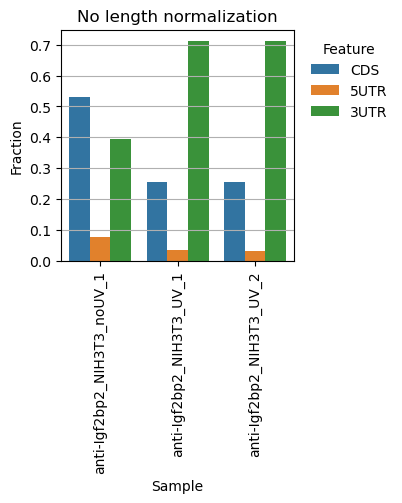

In [177]:
fig, ax = plt.subplots(figsize=(3,3))
sns.barplot(data=df_parts, x='Sample', y='Fraction', hue='Feature', ax=ax)
ax.tick_params(axis='x', rotation=90)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1.02, 1))
legend._loc = 2  # upper left
legend.set_frame_on(False)
ax.grid(axis='y')
plt.title('No length normalization')

### Normalized to feature length

In [178]:
cds_uniq_n = cds_uniq.copy().div(cds_uniq['Length'], axis=0).drop(columns='Length')
utr5_uniq_n = utr5_uniq.copy().div(utr5_uniq['Length'], axis=0).drop(columns='Length')
utr3_uniq_n = utr3_uniq.copy().div(utr3_uniq['Length'], axis=0).drop(columns='Length')
df_parts_n = pd.DataFrame({
    'CDS': cds_uniq_n.sum(),
    "5'UTR": utr5_uniq_n.sum(),
    "3'UTR": utr3_uniq_n.sum()
})
df_parts_n = df_parts_n.apply(lambda x: x / x.sum(), axis=1)
df_parts_n = df_parts_n.melt(var_name='Feature', value_name='Count', ignore_index=False).reset_index()
df_parts_n = df_parts_n.rename(columns={'index':'Sample', 'Count':'Fraction'})

Text(0.5, 1.0, 'Normalized to feature length')

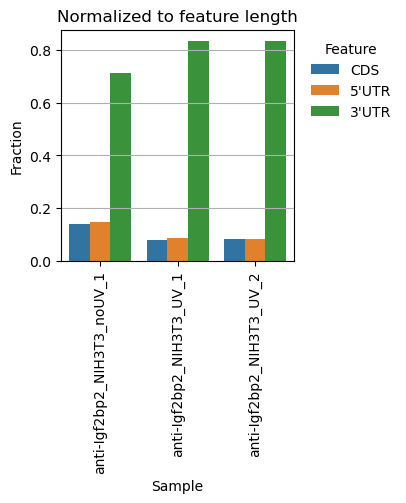

In [179]:
fig, ax = plt.subplots(figsize=(3,3))
sns.barplot(data=df_parts_n, x='Sample', y='Fraction', hue='Feature', ax=ax)
ax.tick_params(axis='x', rotation=90)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1.02, 1))
legend._loc = 2  # upper left
legend.set_frame_on(False)
ax.grid(axis='y')
plt.title('Normalized to feature length')

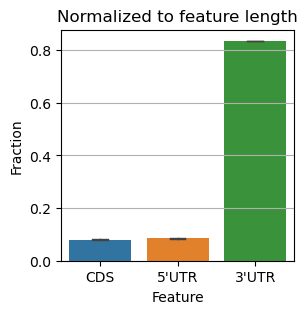

In [180]:
fig, ax = plt.subplots(figsize=(3,3))
sns.barplot(data=df_parts_n[~df_parts_n['Sample'].str.contains('noUV')], x='Feature', y='Fraction', hue='Feature', capsize=0.2, err_kws={'linewidth': 1}, ax=ax)
ax.grid(axis='y')
plt.title('Normalized to feature length')
plt.savefig("00a_5UTR_CDS_3UTR_NIH3T3_normalized.png", dpi=300, bbox_inches='tight')
plt.savefig("00a_5UTR_CDS_3UTR_NIH3T3_normalized.svg", bbox_inches='tight')

## Count tables

In [181]:
hits_cds = (cds_uniq
    .drop(columns='Length')
    .assign(median=cds_uniq[['anti-Igf2bp2_NIH3T3_UV_1','anti-Igf2bp2_NIH3T3_UV_2']].median(axis=1))
    .sort_values('median', ascending=False)
    .drop(columns='median')
    )
hits_cds.to_csv("00a_NIH3T3_CDS_hits_raw.csv")

(cds_uniq_n
    .assign(median=cds_uniq[['anti-Igf2bp2_NIH3T3_UV_1','anti-Igf2bp2_NIH3T3_UV_2']].median(axis=1))
    .sort_values('median', ascending=False)
    .drop(columns='median')
).to_csv("00a_NIH3T3_CDS_hits_normalized.csv")

In [182]:
hits_5utr = (utr5_uniq
    .drop(columns='Length')
    .assign(median=utr5_uniq[['anti-Igf2bp2_NIH3T3_UV_1','anti-Igf2bp2_NIH3T3_UV_2']].median(axis=1))
    .sort_values('median', ascending=False)
    .drop(columns='median')
    )
hits_5utr.to_csv("00a_NIH3T3_5UTR_hits_raw.csv")

(utr5_uniq_n
    .assign(median=utr5_uniq[['anti-Igf2bp2_NIH3T3_UV_1','anti-Igf2bp2_NIH3T3_UV_2']].median(axis=1))
    .sort_values('median', ascending=False)
    .drop(columns='median')
).to_csv("00a_NIH3T3_5UTR_hits_normalized.csv")

In [183]:
hits_3utr = (utr3_uniq
    .drop(columns='Length')
    .assign(median=utr3_uniq[['anti-Igf2bp2_NIH3T3_UV_1','anti-Igf2bp2_NIH3T3_UV_2']].median(axis=1))
    .sort_values('median', ascending=False)
    .drop(columns='median')
    )
hits_3utr.to_csv("00a_NIH3T3_3UTR_hits_raw.csv")

(utr3_uniq_n
    .assign(median=utr3_uniq[['anti-Igf2bp2_NIH3T3_UV_1','anti-Igf2bp2_NIH3T3_UV_2']].median(axis=1))
    .sort_values('median', ascending=False)
    .drop(columns='median')
).to_csv("00a_NIH3T3_3UTR_hits_normalized.csv")